# Implementation – Logistic Regression (Binary Classification)

In [10]:
# Import Libraries & Load Dataset

import pandas as pd
from matplotlib import pyplot as plt
import math
# Load dataset
df = pd.read_csv("HR_comma_sep.csv")

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Overall Leaving Rate:
left
0    11428
1     3571
Name: count, dtype: int64
Leaving Percentage: 0.2380825388359224

Salary vs Leaving Rate:
salary
high      0.066289
low       0.296884
medium    0.204313
Name: left, dtype: float64


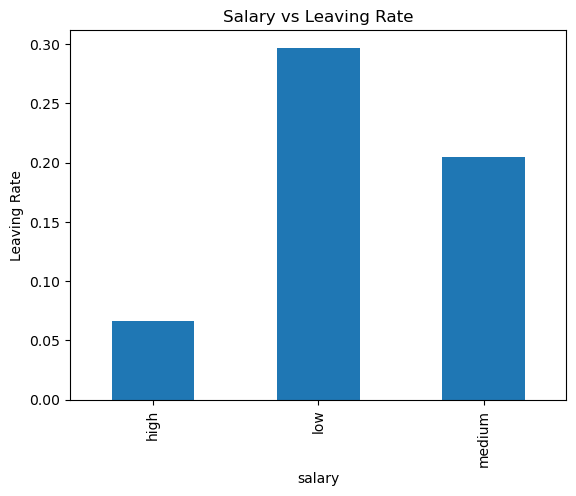


Department vs Leaving Rate:
Department
IT             0.222494
RandD          0.153748
accounting     0.265971
hr             0.290934
management     0.144444
marketing      0.236597
product_mng    0.219512
sales          0.244928
support        0.248991
technical      0.256250
Name: left, dtype: float64


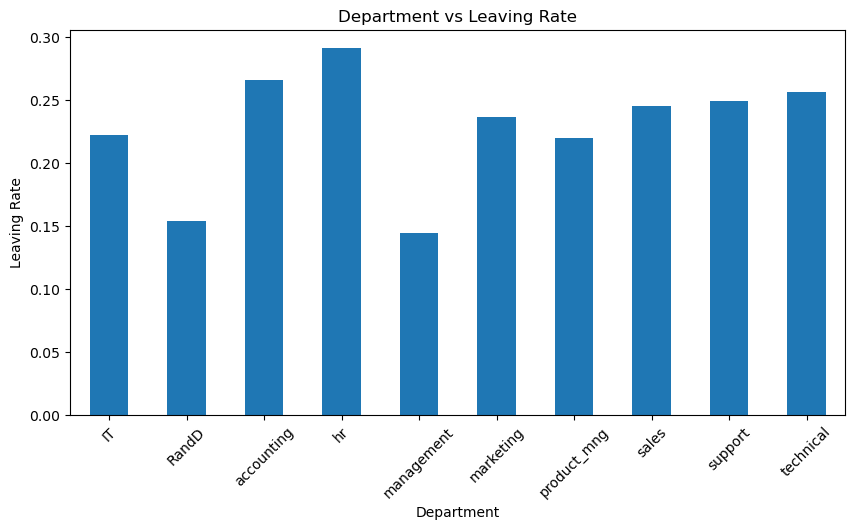


Average Satisfaction (Left vs Stayed):
left
0    0.666810
1    0.440098
Name: satisfaction_level, dtype: float64


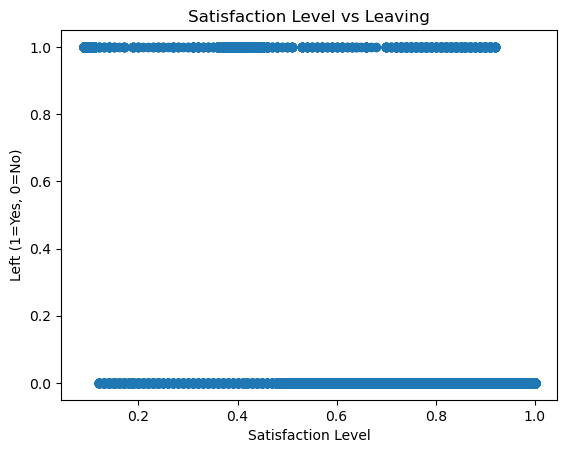


Average Monthly Hours (Left vs Stayed):
left
0    199.060203
1    207.419210
Name: average_montly_hours, dtype: float64

Time Spent in Company (Left vs Stayed):
left
0    3.380032
1    3.876505
Name: time_spend_company, dtype: float64

Promotion vs Leaving Rate:
promotion_last_5years
0    0.241962
1    0.059561
Name: left, dtype: float64


In [11]:
'''step1: Do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention 
(i.e. whether they leave the company or continue to work)
'''

# ==============================
# 1. Check Overall Leaving Rate
# ==============================

print("\nOverall Leaving Rate:")
print(df['left'].value_counts())
print("Leaving Percentage:", df['left'].mean())

# ==============================
# 2. Salary vs Retention
# ==============================

print("\nSalary vs Leaving Rate:")
salary_impact = df.groupby('salary')['left'].mean()
print(salary_impact)

salary_impact.plot(kind='bar')
plt.title("Salary vs Leaving Rate")
plt.ylabel("Leaving Rate")
plt.show()

# ==============================
# 3. Department vs Retention
# ==============================

print("\nDepartment vs Leaving Rate:")
dept_impact = df.groupby('Department')['left'].mean()
print(dept_impact)

dept_impact.plot(kind='bar', figsize=(10,5))
plt.title("Department vs Leaving Rate")
plt.xticks(rotation=45)
plt.ylabel("Leaving Rate")
plt.show()

# ==============================
# 4. Satisfaction Level Impact
# ==============================

print("\nAverage Satisfaction (Left vs Stayed):")
print(df.groupby('left')['satisfaction_level'].mean())

plt.scatter(df['satisfaction_level'], df['left'])
plt.title("Satisfaction Level vs Leaving")
plt.xlabel("Satisfaction Level")
plt.ylabel("Left (1=Yes, 0=No)")
plt.show()

# ==============================
# 5. Monthly Hours Impact
# ==============================

print("\nAverage Monthly Hours (Left vs Stayed):")
print(df.groupby('left')['average_montly_hours'].mean())

# ==============================
# 6. Time Spent in Company Impact
# ==============================

print("\nTime Spent in Company (Left vs Stayed):")
print(df.groupby('left')['time_spend_company'].mean())

# ==============================
# 7. Promotion Impact
# ==============================

print("\nPromotion vs Leaving Rate:")
print(df.groupby('promotion_last_5years')['left'].mean())

salary
high      0.066289
low       0.296884
medium    0.204313
Name: left, dtype: float64


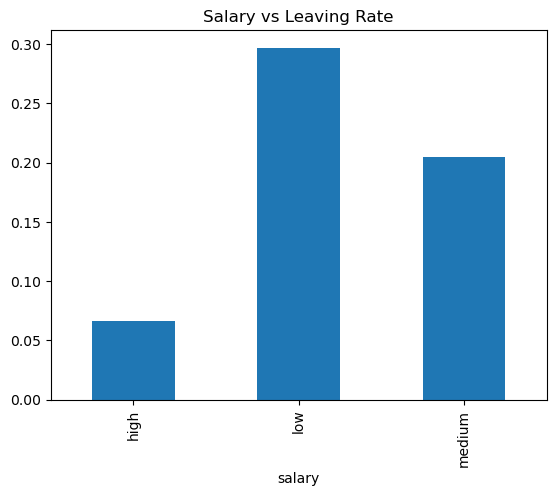

In [12]:
# step 2: Plot bar charts showing impact of employee salaries on retention

salary_left = df.groupby('salary')['left'].mean()
print(salary_left)

salary_left.plot(kind='bar')
plt.title("Salary vs Leaving Rate")
plt.show()

Department
IT             0.222494
RandD          0.153748
accounting     0.265971
hr             0.290934
management     0.144444
marketing      0.236597
product_mng    0.219512
sales          0.244928
support        0.248991
technical      0.256250
Name: left, dtype: float64


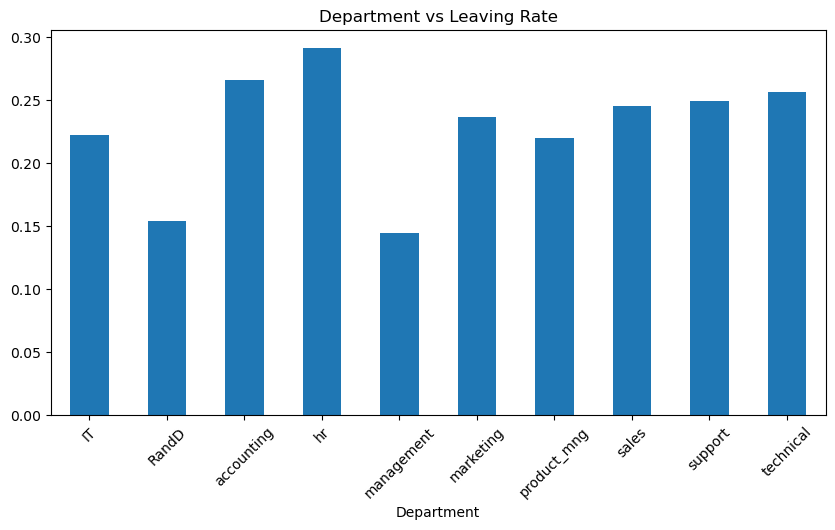

In [13]:
#step 3: Plot bar charts showing corelation between department and employee retention

dept_left = df.groupby('Department')['left'].mean()
print(dept_left)

dept_left.plot(kind='bar', figsize=(10,5))
plt.xticks(rotation=45)
plt.title("Department vs Leaving Rate")
plt.show()

In [14]:
# step 4: Build logistic regression model using variables that were narrowed down in step 1

# =====================================================
# 1. Select Feature for Manual Logistic Regression
#    (Using satisfaction_level)
# =====================================================

X = list(df['satisfaction_level'])
y = list(df['left'])
n = len(X)

# =====================================================
# 2. Define Sigmoid Function
# =====================================================

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# =====================================================
# 3. Initialize Parameters
# =====================================================

w = -5          # weight
b = 2           # bias
learning_rate = 0.1
epochs = 200

# =====================================================
# 4. Manual Gradient Descent Training
# =====================================================

for epoch in range(epochs):
    dw = 0
    db = 0
    
    for i in range(n):
        z = w * X[i] + b
        y_pred = sigmoid(z)
        
        dw += (y_pred - y[i]) * X[i]
        db += (y_pred - y[i])
    
    dw = dw / n
    db = db / n
    
    w = w - learning_rate * dw
    b = b - learning_rate * db

print("\nFinal Weight:", w)
print("Final Bias:", b)

# =====================================================
# 5. Prediction Function
# =====================================================

def predict(x):
    z = w * x + b
    prob = sigmoid(z)
    if prob >= 0.5:
        return 1
    else:
        return 0



Final Weight: -5.008922818674891
Final Bias: 1.605277439759755


In [15]:
# step 5: Measure the accuracy of the model

correct = 0

for i in range(n):
    if predict(X[i]) == y[i]:
        correct += 1

accuracy = correct / n

print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.7548503233548903


# Implementation – Logistic Regression (Multiclass Classification)

First 5 rows of Zoo Dataset:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1      

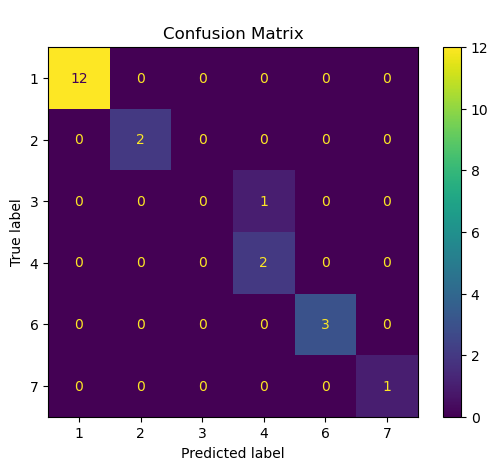

In [16]:
# =====================================================
# 1. Import Libraries
# =====================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics
import matplotlib.pyplot as plt

# =====================================================
# 2. Load Dataset
# =====================================================

zoo = pd.read_csv("zoo-data.csv")
class_type = pd.read_csv("zoo-class-type.csv")

print("First 5 rows of Zoo Dataset:")
print(zoo.head())

# =====================================================
# 3. Data Preprocessing
# =====================================================

# Remove animal name column (not useful for prediction)
zoo = zoo.drop('animal_name', axis=1)

# Features and Target
X = zoo.drop('class_type', axis=1)
y = zoo['class_type']

# =====================================================
# 4. Train-Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================
# 5. Build Multiclass Logistic Regression Model
# =====================================================

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

# =====================================================
# 6. Prediction
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# 7. Accuracy
# =====================================================

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy of Multiclass Logistic Regression Model:", accuracy)

# =====================================================
# 8. Confusion Matrix
# =====================================================

# Create confusion matrix
conf_matrix = metrics.confusion_matrix(y_test, y_pred)

# Get unique labels present in test set
labels = sorted(y_test.unique())

# Display confusion matrix correctly
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=labels
)

cm_display.plot()
plt.title("\nConfusion Matrix")
plt.show()